# Motivation

Tracking driving behavior for ride share services so users can request drivers of specific driving styles or companies can montior employees for overly aggressive driving.

# Imports

In [ ]:
import pandas as pd
import kagglehub
from google.colab import drive, files
import shutil
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import LSTM, GRU

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Flatten



In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading Data

In [ ]:

#download data from kaggle
path = kagglehub.dataset_download("outofskills/driving-behavior")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'driving-behavior' dataset.
Path to dataset files: /kaggle/input/driving-behavior


In [ ]:
drive_path = "/content/drive/MyDrive/Aggressive_Driving"

shutil.copytree(path, drive_path, dirs_exist_ok=True)

'/content/drive/MyDrive/Aggressive_Driving'

In [ ]:
df = pd.read_csv(os.path.join(drive_path, "train_motion_data.csv"))
df.head(30)

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631
5,0.158470,0.345891,0.355274,0.021533,0.115454,0.014584,NORMAL,3581632
6,0.078171,-0.349180,0.270652,0.034361,-0.030543,0.050625,NORMAL,3581632
7,-0.662750,-0.462775,-0.099797,0.008705,-0.009774,0.046960,NORMAL,3581633
8,0.467318,-0.234640,0.134139,-0.048717,-0.020769,-0.030009,NORMAL,3581633
9,-0.171895,-0.408894,0.414653,0.009316,0.058032,-0.019624,NORMAL,3581634


It looks like we have approximately 2 samples per second. We will need to find an appropriate window of time to run our model on.

# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3644 entries, 0 to 3643
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AccX       3644 non-null   float64
 1   AccY       3644 non-null   float64
 2   AccZ       3644 non-null   float64
 3   GyroX      3644 non-null   float64
 4   GyroY      3644 non-null   float64
 5   GyroZ      3644 non-null   float64
 6   Class      3644 non-null   object 
 7   Timestamp  3644 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 227.9+ KB


There's no non-null values for any column, this is a good sign as we don't need to impute anything

In [ ]:
df.describe()

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Timestamp
count,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3.644000e+03
mean,0.040467,-0.073418,0.008271,0.001593,-0.001273,0.007949,3.582707e+06
std,0.985653,0.903408,0.985061,0.066918,0.126205,0.115687,6.421479e+02
min,-4.636523,-4.699795,-7.143998,-0.751822,-1.587028,-1.236468,3.581629e+06
25%,-0.550695,-0.592540,-0.558464,-0.028558,-0.053756,-0.029398,3.582121e+06
50%,0.003931,-0.080833,0.002262,0.001985,-0.001833,0.002978,3.582702e+06
75%,0.595987,0.452401,0.556157,0.031918,0.051313,0.040852,3.583270e+06
max,4.985548,4.245151,5.171739,0.849255,1.679879,1.190500,3.583791e+06


In [ ]:
df["Class"].value_counts()

,count
Class,
SLOW,1331
NORMAL,1200
AGGRESSIVE,1113


In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
SLOW,0.365258
NORMAL,0.329308
AGGRESSIVE,0.305434


The classes are very balanced (around 1/3 each class)

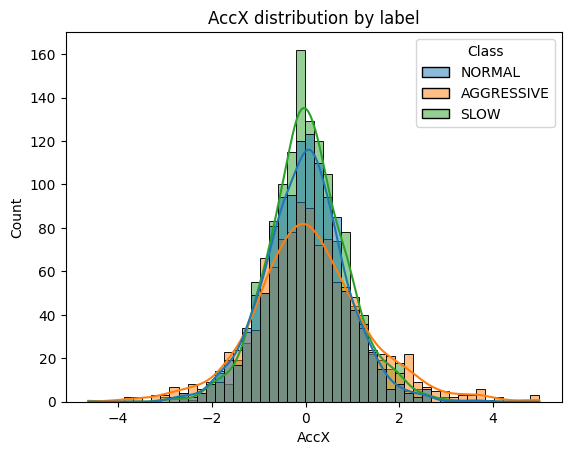

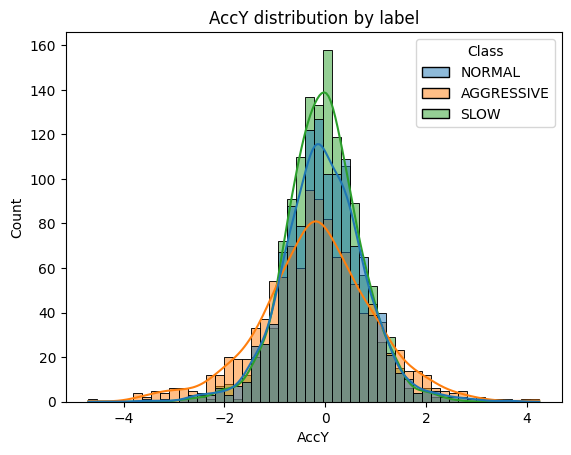

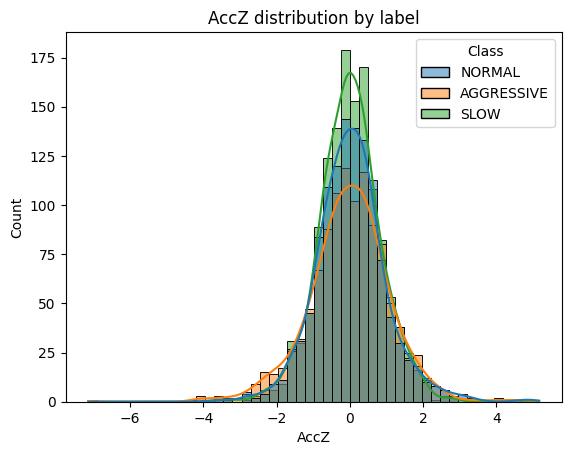

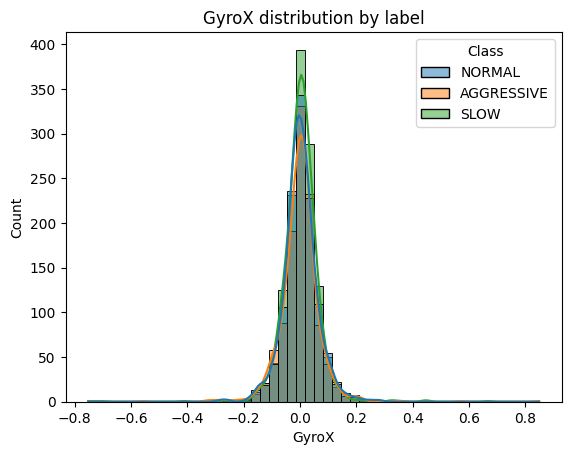

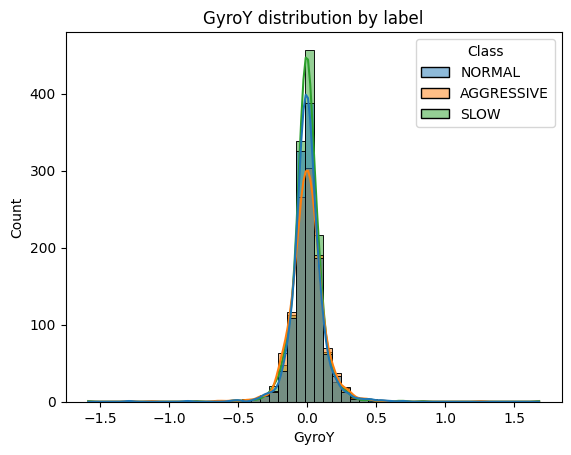

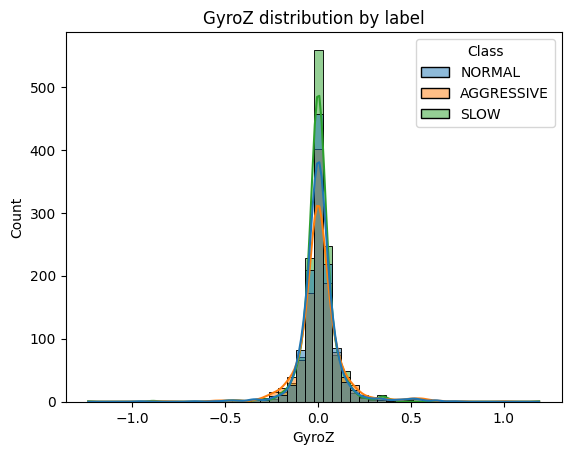

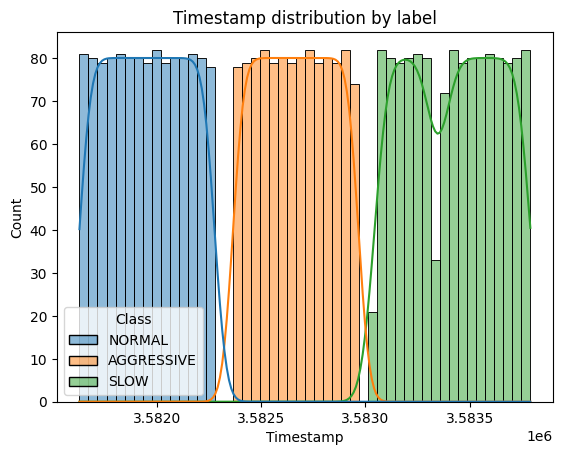

In [ ]:
plot_features = ["AccX","AccY","AccZ","GyroX","GyroY","GyroZ","Timestamp"]

for f in plot_features:
    plt.figure()
    sns.histplot(data=df, x=f, hue="Class", bins=50, kde=True)
    plt.title(f"{f} distribution by label")
    plt.show()

Data appears to be collected in seperate recording sessions for different styles - each distribution is very seperated

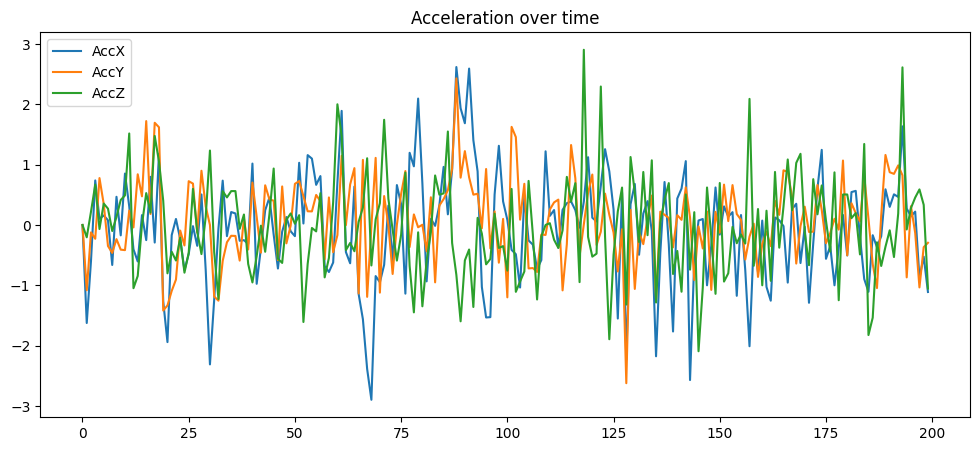

In [ ]:
subset = df.iloc[:200]

plt.figure(figsize=(12,5))
plt.plot(subset["AccX"], label="AccX")
plt.plot(subset["AccY"], label="AccY")
plt.plot(subset["AccZ"], label="AccZ")
plt.legend()
plt.title("Acceleration over time")
plt.show()

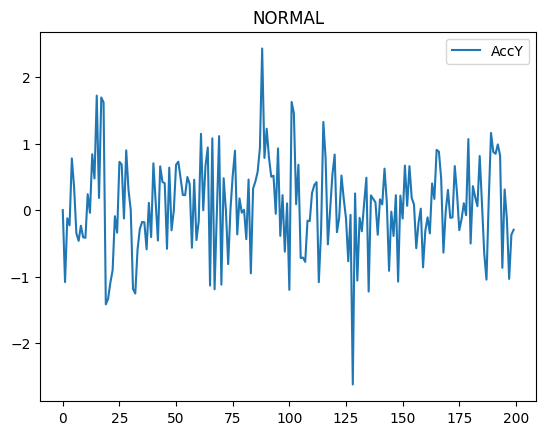

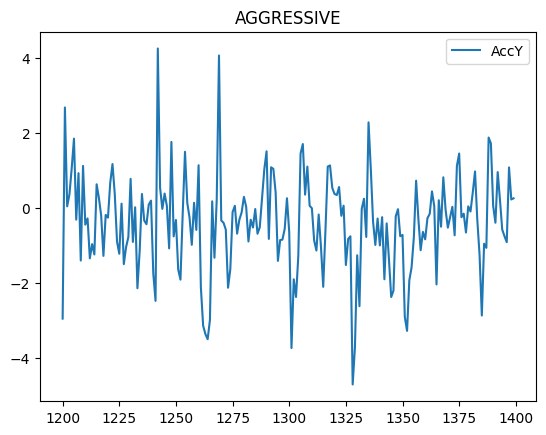

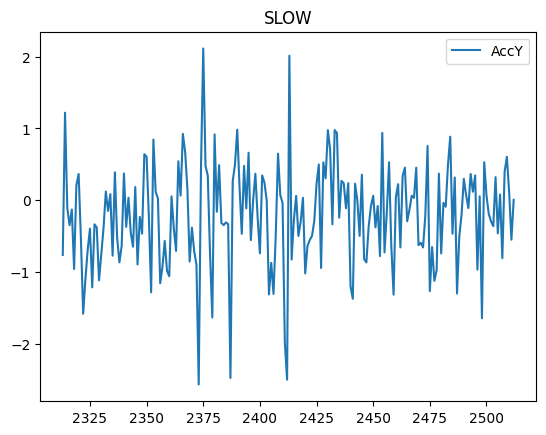

In [ ]:
for label in df["Class"].unique():
    subset = df[df["Class"] == label].iloc[:200]

    plt.figure()
    plt.plot(subset["AccY"], label="AccY")
    plt.title(label)
    plt.legend()
    plt.show()

The plot above shows that aggressive drivers have stronger spikes and slower drivers have smoother signals

# Feature Engineering

### Creating magnitude features from the acc values

In [ ]:
df["acc_mag"] = np.sqrt(df["AccX"]**2 + df["AccY"]**2 + df["AccZ"]**2)
df["gyro_mag"] = np.sqrt(df["GyroX"]**2 + df["GyroY"]**2 + df["GyroZ"]**2)

# Baseline Random Forest

Defining features and target

In [ ]:
features = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "acc_mag", "gyro_mag"]
X = df[features]
y = df["Class"]

Creating train-test split

In [ ]:
X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size = .2, random_state = 42, stratify = y)

Pipeline

In [ ]:
rf = RandomForestClassifier()
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

RF Pipeline

In [ ]:
rf_pipeline = Pipeline([
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])


In [ ]:
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4224965706447188
              precision    recall  f1-score   support

  AGGRESSIVE       0.47      0.36      0.41       223
      NORMAL       0.38      0.39      0.39       240
        SLOW       0.43      0.50      0.46       266

    accuracy                           0.42       729
   macro avg       0.43      0.42      0.42       729
weighted avg       0.43      0.42      0.42       729



Tuning hyperparameters for random forest

In [ ]:
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('rf',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 10, 20],
                         'rf__min_samples_split': [2, 5],
                         'rf__n_estimators': [100, 200]},
             scoring='f1_macro')

In [ ]:
y_pred = grid.predict(X_test)

In [ ]:
print("Best params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Best params: {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Accuracy: 0.4252400548696845
              precision    recall  f1-score   support

  AGGRESSIVE       0.49      0.39      0.43       223
      NORMAL       0.37      0.35      0.36       240
        SLOW       0.43      0.53      0.47       266

    accuracy                           0.43       729
   macro avg       0.43      0.42      0.42       729
weighted avg       0.43      0.43      0.42       729



The tuned random forest is better than a random guesser but still struggles with the task, specifically for normal driviing styles (makes sense as it has less extreme of a signal). A CNN or LSTM is likely better suited for the problem.

# CNN

We need to find a way to break up our train-test data so that when we divide it into windows, we don't get data leakage. Our plan keep each class in timestamp order, split that class's sequence into train/test/val, create windows inside each block, and scale using only the training windows.

However, we note that as each driving style was recorded in seperate sessions, there will still be some bias and the model could learn that a certain setup corresponds to a certain session (sensor orientation or noise...).

In [ ]:
SEED = 42

#python
random.seed(SEED)

#numpy
np.random.seed(SEED)

#tf
tf.random.set_seed(SEED)

In [ ]:
df_cnn = df.copy()

In [ ]:
df_cnn.head()

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp,acc_mag,gyro_mag
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629,0.000000,0.210816
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630,1.963075,0.147711
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630,0.645930,0.094659
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631,1.021474,0.093707
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631,0.787030,0.063007


Defining our features

In [ ]:
features = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "acc_mag", "gyro_mag"]

Encoding our labels

In [ ]:
label_encoder = LabelEncoder()
df_cnn["y"] = label_encoder.fit_transform(df_cnn["Class"])

Defining original window and step sizes

In [ ]:
window_size = 30
step_size = 10

Function to split classes into train-test

In [ ]:
def split_contiguous_sequence(df_cls, train_frac=0.6, val_frac=0.2):
    """
    Split one class's time-ordered dataframe into contiguous train/val/test blocks.
    """
    n = len(df_cls)

    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    df_train = df_cls.iloc[:train_end].copy()
    df_val = df_cls.iloc[train_end:val_end].copy()
    df_test = df_cls.iloc[val_end:].copy()

    return df_train, df_val, df_test

Function to create windows from train-val-test sequence

In [ ]:
def create_windows_from_sequence(X, y, window_size=20, step_size=5):
    """
    Create sliding windows from a contiguous sequence.
    """
    X_windows = []
    y_windows = []

    for i in range(0, len(X) - window_size + 1, step_size):
        X_window = X[i:i + window_size]
        y_window = y[i:i + window_size]

        #majority label in the window
        label = np.bincount(y_window).argmax()

        X_windows.append(X_window)
        y_windows.append(label)

    return np.array(X_windows), np.array(y_windows)

Initializing splits

In [ ]:
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []

Building splits seperately

In [ ]:
#build splits separately for each class
for cls in df_cnn["Class"].unique():
    df_cls = df_cnn[df_cnn["Class"] == cls].sort_values("Timestamp").reset_index(drop=True)

    df_train_cls, df_val_cls, df_test_cls = split_contiguous_sequence(
        df_cls,
        train_frac=0.8,
        val_frac=0.2
    )

    #train windows
    X_seq = df_train_cls[features].values
    y_seq = df_train_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_train_list.append(Xw)
        y_train_list.append(yw)

    #val windows
    X_seq = df_val_cls[features].values
    y_seq = df_val_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_val_list.append(Xw)
        y_val_list.append(yw)


Combining all classes

In [ ]:
X_train_win = np.concatenate(X_train_list, axis=0)
y_train_win = np.concatenate(y_train_list, axis=0)

X_val_win = np.concatenate(X_val_list, axis=0)
y_val_win = np.concatenate(y_val_list, axis=0)

print("Train windows:", X_train_win.shape, y_train_win.shape)
print("Val windows:", X_val_win.shape, y_val_win.shape)


Train windows: (285, 30, 8) (285,)
Val windows: (66, 30, 8) (66,)


Scaling training data

In [ ]:
scaler = StandardScaler()

In [ ]:
n_train, win_len, n_feat = X_train_win.shape
n_val = X_val_win.shape[0]

X_train_2d = X_train_win.reshape(-1, n_feat)
X_val_2d = X_val_win.reshape(-1, n_feat)

X_train_2d = scaler.fit_transform(X_train_2d)
X_val_2d = scaler.transform(X_val_2d)

X_train_final = X_train_2d.reshape(n_train, win_len, n_feat)
X_val_final = X_val_2d.reshape(n_val, win_len, n_feat)


In [ ]:
idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[idx]
y_train_win = y_train_win[idx]

Now, we define parameters for our model

In [ ]:
num_features = X_train_final.shape[2]

In [ ]:
num_classes = len(label_encoder.classes_)

Training the CNN with a variety of random seeds to produce average result

In [ ]:
train_loss_histories = []
val_loss_histories = []

all_accuracies = []
all_reports = []

train_acc_histories = []
val_acc_histories = []

seeds = [1, 2, 3, 4, 5]

for seed in seeds:
    tf.keras.backend.clear_session()
    #set seeds
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    #create model
    cnn_model = Sequential([
    Input(shape=(window_size, num_features)),

    Conv1D(64, 5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation="relu", padding="same"),
    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")])

    #optimizer
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4)

    #compile
    cnn_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

    #callbacks
    early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

    reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1)

    #class weights
    class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_win),
    y=y_train_win)

    class_weights = dict(enumerate(class_weights))

    #train model
    history = cnn_model.fit(
    X_train_final,
    y_train_win,
    validation_data=(X_val_final, y_val_win),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight = class_weights,
    verbose = 0)

    train_loss_histories.append(history.history["loss"])
    val_loss_histories.append(history.history["val_loss"])

    train_acc_histories.append(history.history["accuracy"])
    val_acc_histories.append(history.history["val_accuracy"])

    #predictions
    y_pred_probs = cnn_model.predict(X_val_final)
    y_pred = np.argmax(y_pred_probs, axis=1)

    #store accuracies
    acc = accuracy_score(y_val_win, y_pred)
    all_accuracies.append(acc)

    #get report as dict
    report = classification_report(
        y_val_win,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    all_reports.append(report)


Epoch 38: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step

Epoch 47: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

Epoch 38: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step

Epoch 24: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step

Epoch 41: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


Average metrics

In [ ]:
classes = label_encoder.classes_

avg_metrics = {}

for cls in classes:
    precision = []
    recall = []
    f1 = []

    for report in all_reports:
        precision.append(report[cls]["precision"])
        recall.append(report[cls]["recall"])
        f1.append(report[cls]["f1-score"])

    avg_metrics[cls] = {
        "precision_mean": np.mean(precision),
        "precision_std": np.std(precision),
        "recall_mean": np.mean(recall),
        "recall_std": np.std(recall),
        "f1_mean": np.mean(f1),
        "f1_std": np.std(f1),
    }

mean_acc = np.mean(all_accuracies)
std_acc = np.std(all_accuracies)

In [ ]:
print("\n=== Per-Class Metrics ===")

for cls, metrics in avg_metrics.items():
    print(f"\nClass: {cls}")
    print(f"  Precision: {metrics['precision_mean']:.3f} ± {metrics['precision_std']:.3f}")
    print(f"  Recall:    {metrics['recall_mean']:.3f} ± {metrics['recall_std']:.3f}")
    print(f"  F1-score:  {metrics['f1_mean']:.3f} ± {metrics['f1_std']:.3f}")

print("\n=== Overall Performance ===")
print(f"Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")


=== Per-Class Metrics ===

Class: AGGRESSIVE
  Precision: 0.648 ± 0.051
  Recall:    0.930 ± 0.040
  F1-score:  0.763 ± 0.045

Class: NORMAL
  Precision: 0.388 ± 0.211
  Recall:    0.209 ± 0.143
  F1-score:  0.259 ± 0.153

Class: SLOW
  Precision: 0.604 ± 0.048
  Recall:    0.675 ± 0.178
  F1-score:  0.621 ± 0.097

=== Overall Performance ===
Accuracy: 0.597 ± 0.042


Validation and loss curves

In [ ]:
def pad_histories(histories):
    max_len = max(len(h) for h in histories)
    padded = np.full((len(histories), max_len), np.nan)

    for i, h in enumerate(histories):
        padded[i, :len(h)] = h

    return padded

In [ ]:
train_loss_padded = pad_histories(train_loss_histories)
val_loss_padded   = pad_histories(val_loss_histories)

train_acc_padded = pad_histories(train_acc_histories)
val_acc_padded   = pad_histories(val_acc_histories)

In [ ]:
mean_train_loss = np.nanmean(train_loss_padded, axis=0)
std_train_loss  = np.nanstd(train_loss_padded, axis=0)

mean_val_loss = np.nanmean(val_loss_padded, axis=0)
std_val_loss  = np.nanstd(val_loss_padded, axis=0)

mean_train_acc = np.nanmean(train_acc_padded, axis=0)
std_train_acc  = np.nanstd(train_acc_padded, axis=0)

mean_val_acc = np.nanmean(val_acc_padded, axis=0)
std_val_acc  = np.nanstd(val_acc_padded, axis=0)

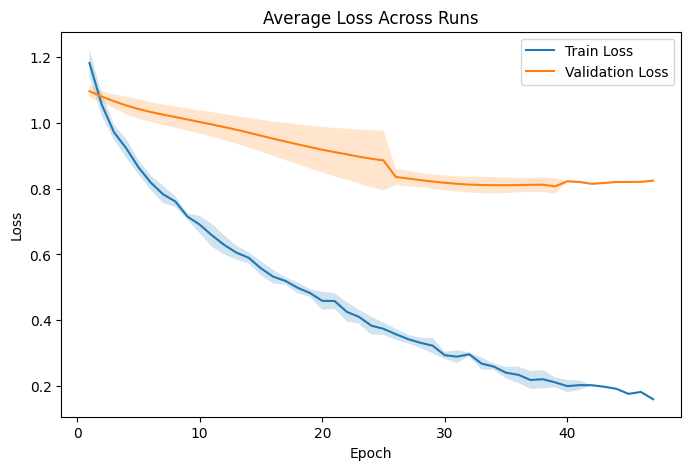

In [ ]:
epochs = np.arange(1, len(mean_train_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_train_loss, label="Train Loss")
plt.plot(epochs, mean_val_loss, label="Validation Loss")

plt.fill_between(
    epochs,
    mean_train_loss - std_train_loss,
    mean_train_loss + std_train_loss,
    alpha=0.2
)

plt.fill_between(
    epochs,
    mean_val_loss - std_val_loss,
    mean_val_loss + std_val_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Average Loss Across Runs")
plt.legend()
plt.show()

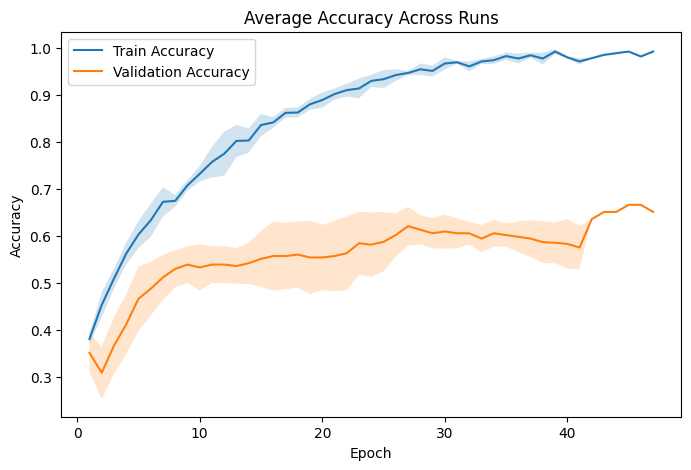

In [ ]:
epochs = np.arange(1, len(mean_train_acc) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_train_acc, label="Train Accuracy")
plt.plot(epochs, mean_val_acc, label="Validation Accuracy")

plt.fill_between(
    epochs,
    mean_train_acc - std_train_acc,
    mean_train_acc + std_train_acc,
    alpha=0.2
)

plt.fill_between(
    epochs,
    mean_val_acc - std_val_acc,
    mean_val_acc + std_val_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Average Accuracy Across Runs")
plt.legend()
plt.show()

Our CNN has substatially improved accuracy over the RF, but still underpredicts on normal class. This is likely because there is no distinct normal signal. However, for the purpose of identifying notably fast/slow drivers, this model would work. Now, we try a CNN + LSTM and a CNN +GRU

# CNN + GRU

Setting window size and lists

In [ ]:
window_size = 20
step_size = 5

In [ ]:
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []

Building lists for each class

In [ ]:
#build splits separately for each class
for cls in df_cnn["Class"].unique():
    df_cls = df_cnn[df_cnn["Class"] == cls].sort_values("Timestamp").reset_index(drop=True)

    df_train_cls, df_val_cls, df_test_cls = split_contiguous_sequence(
        df_cls,
        train_frac=0.8,
        val_frac=0.2
    )

    #train windows
    X_seq = df_train_cls[features].values
    y_seq = df_train_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_train_list.append(Xw)
        y_train_list.append(yw)

    #val windows
    X_seq = df_val_cls[features].values
    y_seq = df_val_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_val_list.append(Xw)
        y_val_list.append(yw)


Combining all classes

In [ ]:
X_train_win = np.concatenate(X_train_list, axis=0)
y_train_win = np.concatenate(y_train_list, axis=0)

X_val_win = np.concatenate(X_val_list, axis=0)
y_val_win = np.concatenate(y_val_list, axis=0)

print("Train windows:", X_train_win.shape, y_train_win.shape)
print("Val windows:", X_val_win.shape, y_val_win.shape)


Train windows: (573, 20, 8) (573,)
Val windows: (136, 20, 8) (136,)


Scaling training data

In [ ]:
scaler = StandardScaler()

In [ ]:
n_train, win_len, n_feat = X_train_win.shape
n_val = X_val_win.shape[0]

X_train_2d = X_train_win.reshape(-1, n_feat)
X_val_2d = X_val_win.reshape(-1, n_feat)

X_train_2d = scaler.fit_transform(X_train_2d)
X_val_2d = scaler.transform(X_val_2d)

X_train_final = X_train_2d.reshape(n_train, win_len, n_feat)
X_val_final = X_val_2d.reshape(n_val, win_len, n_feat)


Shuffling training data

In [ ]:
idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[idx]
y_train_win = y_train_win[idx]

Building splits and training

In [ ]:
#build splits separately for each class
for cls in df_cnn["Class"].unique():
    df_cls = df_cnn[df_cnn["Class"] == cls].sort_values("Timestamp").reset_index(drop=True)

    df_train_cls, df_val_cls, df_test_cls = split_contiguous_sequence(
        df_cls,
        train_frac=0.8,
        val_frac=0.2
    )

    #train windows
    X_seq = df_train_cls[features].values
    y_seq = df_train_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_train_list.append(Xw)
        y_train_list.append(yw)

    #val windows
    X_seq = df_val_cls[features].values
    y_seq = df_val_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_val_list.append(Xw)
        y_val_list.append(yw)


In [ ]:
train_loss_histories = []
val_loss_histories = []

all_accuracies = []
all_reports = []

train_acc_histories = []
val_acc_histories = []

seeds = [1, 2, 3, 4, 5]

for seed in seeds:
    tf.keras.backend.clear_session()
    #set seeds
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    #create model
    gru_model = Sequential([
    Input(shape=(window_size, num_features)),

    Conv1D(64, 5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation="relu", padding="same"),
    BatchNormalization(),

    GRU(64, dropout = .2, recurrent_dropout = .2),

    Dense(64, activation="relu"),
    Dropout(0.4),

    Dense(num_classes, activation="softmax")])

    #optimizer
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4)

    #compile
    gru_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

    #callbacks
    early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

    reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1)

    #class weights
    class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_win),
    y=y_train_win)

    class_weights = dict(enumerate(class_weights))

    #train model
    history = gru_model.fit(
    X_train_final,
    y_train_win,
    validation_data=(X_val_final, y_val_win),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight = class_weights,
    verbose = 0)

    train_loss_histories.append(history.history["loss"])
    val_loss_histories.append(history.history["val_loss"])

    train_acc_histories.append(history.history["accuracy"])
    val_acc_histories.append(history.history["val_accuracy"])

    #predictions
    y_pred_probs = gru_model.predict(X_val_final)
    y_pred = np.argmax(y_pred_probs, axis=1)

    #store accuracies
    acc = accuracy_score(y_val_win, y_pred)
    all_accuracies.append(acc)

    #get report as dict
    report = classification_report(
        y_val_win,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    all_reports.append(report)


Epoch 38: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step

Epoch 38: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step

Epoch 26: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step

Epoch 28: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step

Epoch 21: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step


Average metrics

In [ ]:
classes = label_encoder.classes_

avg_metrics = {}

for cls in classes:
    precision = []
    recall = []
    f1 = []

    for report in all_reports:
        precision.append(report[cls]["precision"])
        recall.append(report[cls]["recall"])
        f1.append(report[cls]["f1-score"])

    avg_metrics[cls] = {
        "precision_mean": np.mean(precision),
        "precision_std": np.std(precision),
        "recall_mean": np.mean(recall),
        "recall_std": np.std(recall),
        "f1_mean": np.mean(f1),
        "f1_std": np.std(f1),
    }

mean_acc = np.mean(all_accuracies)
std_acc = np.std(all_accuracies)

In [ ]:
print("\n=== Per-Class Metrics ===")

for cls, metrics in avg_metrics.items():
    print(f"\nClass: {cls}")
    print(f"  Precision: {metrics['precision_mean']:.3f} ± {metrics['precision_std']:.3f}")
    print(f"  Recall:    {metrics['recall_mean']:.3f} ± {metrics['recall_std']:.3f}")
    print(f"  F1-score:  {metrics['f1_mean']:.3f} ± {metrics['f1_std']:.3f}")

print("\n=== Overall Performance ===")
print(f"Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")


=== Per-Class Metrics ===

Class: AGGRESSIVE
  Precision: 0.551 ± 0.033
  Recall:    0.839 ± 0.053
  F1-score:  0.664 ± 0.035

Class: NORMAL
  Precision: 0.381 ± 0.043
  Recall:    0.258 ± 0.062
  F1-score:  0.305 ± 0.050

Class: SLOW
  Precision: 0.529 ± 0.060
  Recall:    0.456 ± 0.099
  F1-score:  0.487 ± 0.078

=== Overall Performance ===
Accuracy: 0.506 ± 0.042


Validation and loss curves

In [ ]:
def pad_histories(histories):
    max_len = max(len(h) for h in histories)
    padded = np.full((len(histories), max_len), np.nan)

    for i, h in enumerate(histories):
        padded[i, :len(h)] = h

    return padded

In [ ]:
train_loss_padded = pad_histories(train_loss_histories)
val_loss_padded   = pad_histories(val_loss_histories)

train_acc_padded = pad_histories(train_acc_histories)
val_acc_padded   = pad_histories(val_acc_histories)

In [ ]:
mean_train_loss = np.nanmean(train_loss_padded, axis=0)
std_train_loss  = np.nanstd(train_loss_padded, axis=0)

mean_val_loss = np.nanmean(val_loss_padded, axis=0)
std_val_loss  = np.nanstd(val_loss_padded, axis=0)

mean_train_acc = np.nanmean(train_acc_padded, axis=0)
std_train_acc  = np.nanstd(train_acc_padded, axis=0)

mean_val_acc = np.nanmean(val_acc_padded, axis=0)
std_val_acc  = np.nanstd(val_acc_padded, axis=0)

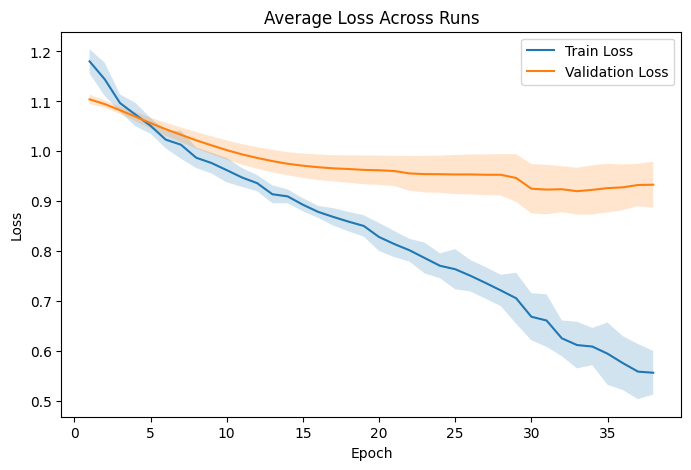

In [ ]:
epochs = np.arange(1, len(mean_train_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_train_loss, label="Train Loss")
plt.plot(epochs, mean_val_loss, label="Validation Loss")

plt.fill_between(
    epochs,
    mean_train_loss - std_train_loss,
    mean_train_loss + std_train_loss,
    alpha=0.2
)

plt.fill_between(
    epochs,
    mean_val_loss - std_val_loss,
    mean_val_loss + std_val_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Average Loss Across Runs")
plt.legend()
plt.show()

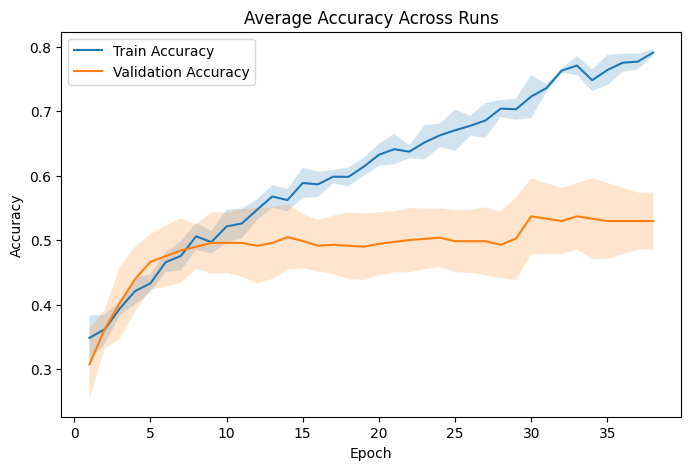

In [ ]:
epochs = np.arange(1, len(mean_train_acc) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_train_acc, label="Train Accuracy")
plt.plot(epochs, mean_val_acc, label="Validation Accuracy")

plt.fill_between(
    epochs,
    mean_train_acc - std_train_acc,
    mean_train_acc + std_train_acc,
    alpha=0.2
)

plt.fill_between(
    epochs,
    mean_val_acc - std_val_acc,
    mean_val_acc + std_val_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Average Accuracy Across Runs")
plt.legend()
plt.show()

# CNN + LSTM

Setting window size and making lists

In [ ]:
window_size = 20
step_size = 5

In [ ]:
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []

Building lists for each class

In [ ]:
#build splits separately for each class
for cls in df_cnn["Class"].unique():
    df_cls = df_cnn[df_cnn["Class"] == cls].sort_values("Timestamp").reset_index(drop=True)

    df_train_cls, df_val_cls, df_test_cls = split_contiguous_sequence(
        df_cls,
        train_frac=0.8,
        val_frac=0.2
    )

    #train windows
    X_seq = df_train_cls[features].values
    y_seq = df_train_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_train_list.append(Xw)
        y_train_list.append(yw)

    #val windows
    X_seq = df_val_cls[features].values
    y_seq = df_val_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_val_list.append(Xw)
        y_val_list.append(yw)


Combining all classes

In [ ]:
X_train_win = np.concatenate(X_train_list, axis=0)
y_train_win = np.concatenate(y_train_list, axis=0)

X_val_win = np.concatenate(X_val_list, axis=0)
y_val_win = np.concatenate(y_val_list, axis=0)

print("Train windows:", X_train_win.shape, y_train_win.shape)
print("Val windows:", X_val_win.shape, y_val_win.shape)


Train windows: (573, 20, 8) (573,)
Val windows: (136, 20, 8) (136,)


Scaling training data

In [ ]:
scaler = StandardScaler()

In [ ]:
n_train, win_len, n_feat = X_train_win.shape
n_val = X_val_win.shape[0]

X_train_2d = X_train_win.reshape(-1, n_feat)
X_val_2d = X_val_win.reshape(-1, n_feat)

X_train_2d = scaler.fit_transform(X_train_2d)
X_val_2d = scaler.transform(X_val_2d)

X_train_final = X_train_2d.reshape(n_train, win_len, n_feat)
X_val_final = X_val_2d.reshape(n_val, win_len, n_feat)


Shuffle training data

In [ ]:
idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[idx]
y_train_win = y_train_win[idx]

In [ ]:
#build splits separately for each class
for cls in df_cnn["Class"].unique():
    df_cls = df_cnn[df_cnn["Class"] == cls].sort_values("Timestamp").reset_index(drop=True)

    df_train_cls, df_val_cls, df_test_cls = split_contiguous_sequence(
        df_cls,
        train_frac=0.8,
        val_frac=0.2
    )

    #train windows
    X_seq = df_train_cls[features].values
    y_seq = df_train_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_train_list.append(Xw)
        y_train_list.append(yw)

    #val windows
    X_seq = df_val_cls[features].values
    y_seq = df_val_cls["y"].values
    if len(X_seq) >= window_size:
        Xw, yw = create_windows_from_sequence(X_seq, y_seq, window_size, step_size)
        X_val_list.append(Xw)
        y_val_list.append(yw)


In [ ]:
train_loss_histories = []
val_loss_histories = []

all_accuracies = []
all_reports = []

train_acc_histories = []
val_acc_histories = []

seeds = [1, 2, 3, 4, 5]

for seed in seeds:
    tf.keras.backend.clear_session()
    #set seeds
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    #create model
    lstm_model = Sequential([
    Input(shape=(window_size, num_features)),

    Conv1D(64, 5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation="relu", padding="same"),
    BatchNormalization(),

    LSTM(64, dropout = .2, recurrent_dropout = .2),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")])

    #optimizer
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4)

    #compile
    lstm_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

    #callbacks
    early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

    reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1)

    #class weights
    class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_win),
    y=y_train_win)

    class_weights = dict(enumerate(class_weights))

    #train model
    history = lstm_model.fit(
    X_train_final,
    y_train_win,
    validation_data=(X_val_final, y_val_win),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight = class_weights,
    verbose = 0)

    train_loss_histories.append(history.history["loss"])
    val_loss_histories.append(history.history["val_loss"])

    train_acc_histories.append(history.history["accuracy"])
    val_acc_histories.append(history.history["val_accuracy"])

    #predictions
    y_pred_probs = lstm_model.predict(X_val_final)
    y_pred = np.argmax(y_pred_probs, axis=1)

    #store accuracies
    acc = accuracy_score(y_val_win, y_pred)
    all_accuracies.append(acc)

    #get report as dict
    report = classification_report(
        y_val_win,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    all_reports.append(report)


Epoch 44: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step

Epoch 40: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step

Epoch 37: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step

Epoch 35: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step

Epoch 42: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step


Average metrics

In [ ]:
classes = label_encoder.classes_

avg_metrics = {}

for cls in classes:
    precision = []
    recall = []
    f1 = []

    for report in all_reports:
        precision.append(report[cls]["precision"])
        recall.append(report[cls]["recall"])
        f1.append(report[cls]["f1-score"])

    avg_metrics[cls] = {
        "precision_mean": np.mean(precision),
        "precision_std": np.std(precision),
        "recall_mean": np.mean(recall),
        "recall_std": np.std(recall),
        "f1_mean": np.mean(f1),
        "f1_std": np.std(f1),
    }

mean_acc = np.mean(all_accuracies)
std_acc = np.std(all_accuracies)

In [ ]:
print("\n=== Per-Class Metrics ===")

for cls, metrics in avg_metrics.items():
    print(f"\nClass: {cls}")
    print(f"  Precision: {metrics['precision_mean']:.3f} ± {metrics['precision_std']:.3f}")
    print(f"  Recall:    {metrics['recall_mean']:.3f} ± {metrics['recall_std']:.3f}")
    print(f"  F1-score:  {metrics['f1_mean']:.3f} ± {metrics['f1_std']:.3f}")

print("\n=== Overall Performance ===")
print(f"Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")


=== Per-Class Metrics ===

Class: AGGRESSIVE
  Precision: 0.590 ± 0.054
  Recall:    0.902 ± 0.038
  F1-score:  0.713 ± 0.051

Class: NORMAL
  Precision: 0.365 ± 0.047
  Recall:    0.204 ± 0.071
  F1-score:  0.256 ± 0.070

Class: SLOW
  Precision: 0.596 ± 0.042
  Recall:    0.568 ± 0.068
  F1-score:  0.580 ± 0.045

=== Overall Performance ===
Accuracy: 0.549 ± 0.032


Validation and loss curves

In [ ]:
def pad_histories(histories):
    max_len = max(len(h) for h in histories)
    padded = np.full((len(histories), max_len), np.nan)

    for i, h in enumerate(histories):
        padded[i, :len(h)] = h

    return padded

In [ ]:
train_loss_padded = pad_histories(train_loss_histories)
val_loss_padded   = pad_histories(val_loss_histories)

train_acc_padded = pad_histories(train_acc_histories)
val_acc_padded   = pad_histories(val_acc_histories)

In [ ]:
mean_train_loss = np.nanmean(train_loss_padded, axis=0)
std_train_loss  = np.nanstd(train_loss_padded, axis=0)

mean_val_loss = np.nanmean(val_loss_padded, axis=0)
std_val_loss  = np.nanstd(val_loss_padded, axis=0)

mean_train_acc = np.nanmean(train_acc_padded, axis=0)
std_train_acc  = np.nanstd(train_acc_padded, axis=0)

mean_val_acc = np.nanmean(val_acc_padded, axis=0)
std_val_acc  = np.nanstd(val_acc_padded, axis=0)

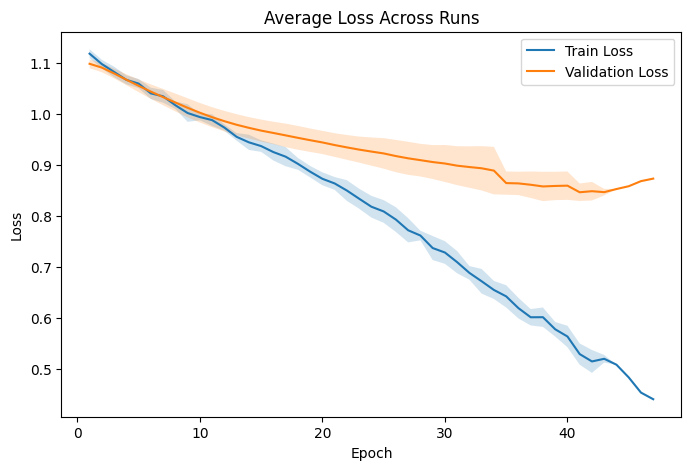

In [ ]:
epochs = np.arange(1, len(mean_train_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_train_loss, label="Train Loss")
plt.plot(epochs, mean_val_loss, label="Validation Loss")

plt.fill_between(
    epochs,
    mean_train_loss - std_train_loss,
    mean_train_loss + std_train_loss,
    alpha=0.2
)

plt.fill_between(
    epochs,
    mean_val_loss - std_val_loss,
    mean_val_loss + std_val_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Average Loss Across Runs")
plt.legend()
plt.show()

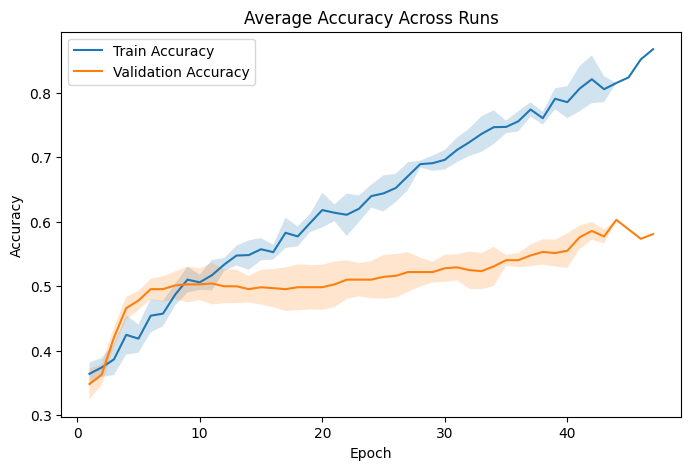

In [ ]:
epochs = np.arange(1, len(mean_train_acc) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_train_acc, label="Train Accuracy")
plt.plot(epochs, mean_val_acc, label="Validation Accuracy")

plt.fill_between(
    epochs,
    mean_train_acc - std_train_acc,
    mean_train_acc + std_train_acc,
    alpha=0.2
)

plt.fill_between(
    epochs,
    mean_val_acc - std_val_acc,
    mean_val_acc + std_val_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Average Accuracy Across Runs")
plt.legend()
plt.show()